# Online vs Batch Processing

This tutorial explains the two processing modes in Fast BOCPD and when to use each one.

## What You'll Learn

- The difference between online and batch (aka offline) processing
- When to use each mode
- How to use `OnlineChangeDetector` for streaming applications
- Performance considerations

## Prerequisites

Complete the Quickstart tutorial (01_quickstart.ipynb) first.

---

## Setup

Import the necessary libraries and check installation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Check installation
try:
    from fast_bocpd import BOCPD, GaussianNIG, ConstantHazard, is_available, OnlineChangeDetector
    assert is_available(), "C library not compiled"
    print("✓ Fast BOCPD is ready!")
except ImportError:
    print("Please install: pip install -e .")
except AssertionError:
    print("C library not compiled. Run: make lib")

✓ Fast BOCPD is ready!


---
## 1. Understanding the Two Modes

Fast BOCPD supports two processing modes:

### Batch / Offline Mode
Process all data at once. The algorithm still works sequentially (causally) through the data, but you provide all observations upfront.

**Use when:**
- You have historical data to analyze
- You want to find all changepoints in a dataset
- Performance is important (minimizes Python overhead)

### Online Mode  
Process one observation at a time. Ideal for streaming data where observations arrive sequentially.

**Use when:**
- Data arrives in real-time
- You need immediate changepoint detection
- Working with streaming sources (sensors, APIs, databases)
- Memory is constrained (don't want to load all data)

**Key Point:** Both modes produce identical results. The difference is how you provide the data.

---
## 2. Batch Mode Example

Let's start with batch processing of historical data.

In [2]:
# Generate synthetic data with changepoints
np.random.seed(42)
data = np.concatenate([
    np.random.randn(100) * 0.5 + 0.0,
    np.random.randn(100) * 0.5 + 5.0,
    np.random.randn(100) * 0.5 + -2.0
])

print(f"Generated {len(data)} observations with changepoints at t=100 and t=200")

# Configure BOCPD
model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
hazard = ConstantHazard(lambda_=100)
bocpd = BOCPD(model, hazard, max_run_length=200)

# Process all data at once
start_time = time.perf_counter()
cp_probs_batch = bocpd.batch_update(data)
batch_time = time.perf_counter() - start_time

print(f"\nBatch processing completed in {batch_time:.4f} seconds")
print(f"Processed {len(data)} observations")

Generated 300 observations with changepoints at t=100 and t=200

Batch processing completed in 0.0041 seconds
Processed 300 observations


---
## 3. Online Mode Example

Now let's process the same data one observation at a time.

In [3]:
# Reset BOCPD to initial state
bocpd.reset()

# Process observations sequentially
cp_probs_online = []
start_time = time.perf_counter()

for x in data:
    posterior_r, cp_prob = bocpd.update(x)
    cp_probs_online.append(cp_prob)

online_time = time.perf_counter() - start_time

print(f"Online processing completed in {online_time:.4f} seconds")
print(f"Processed {len(data)} observations")

# Verify results are identical
match = np.allclose(cp_probs_batch, cp_probs_online)
print(f"\nResults match: {match}")
print(f"Maximum difference: {np.max(np.abs(cp_probs_batch - cp_probs_online)):.8}")

Online processing completed in 0.0062 seconds
Processed 300 observations

Results match: True
Maximum difference: 0.0


---
## 4. Performance Comparison

Let's visualize the results and compare performance.

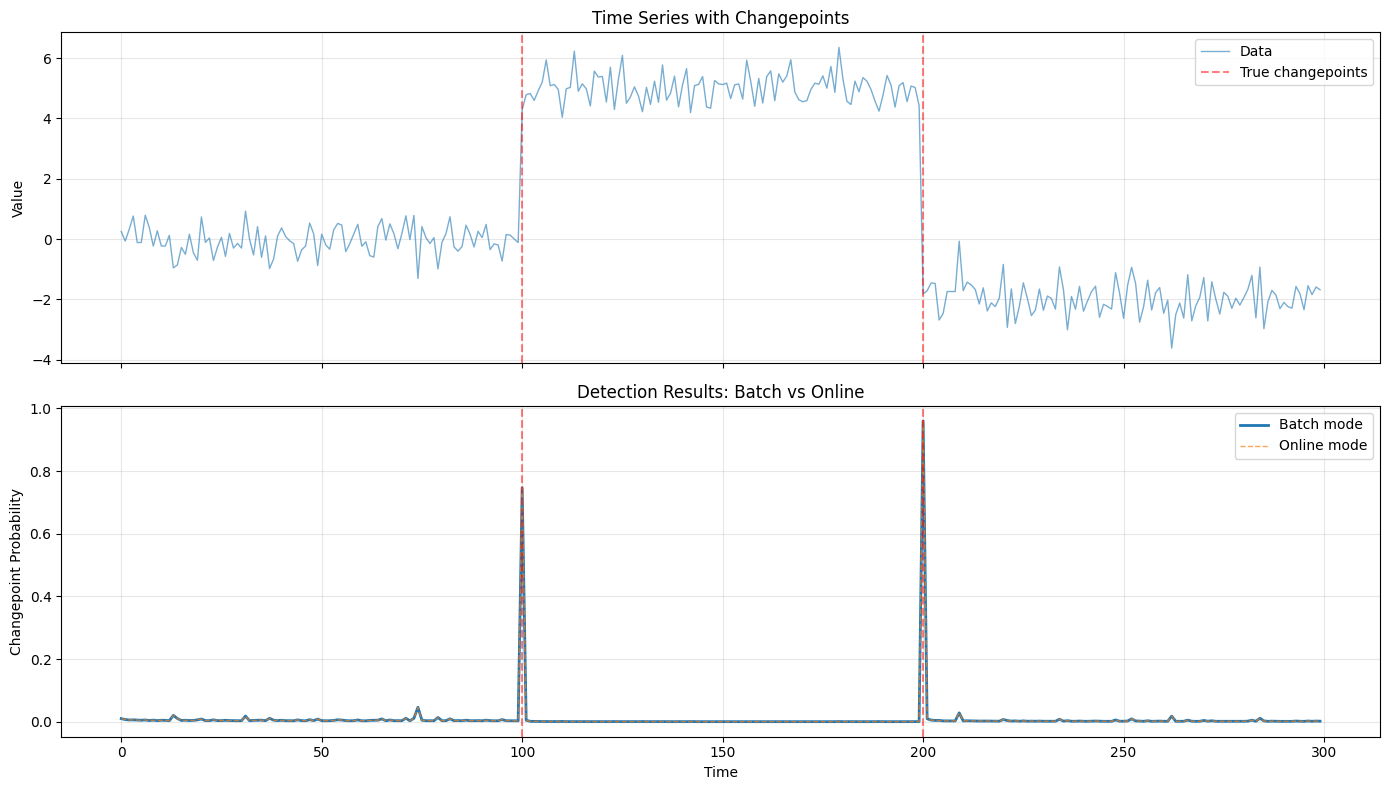


Performance Summary:
  Batch mode:  0.0041 seconds
  Online mode: 0.0062 seconds
  Speedup:     1.52x

Note: Batch mode is faster due to reduced Python overhead


In [4]:
# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Data with true changepoints
ax1.plot(data, alpha=0.6, linewidth=1, label='Data')
ax1.axvline(100, color='red', linestyle='--', alpha=0.5, label='True changepoints')
ax1.axvline(200, color='red', linestyle='--', alpha=0.5)
ax1.set_ylabel('Value')
ax1.set_title('Time Series with Changepoints')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Changepoint probabilities
ax2.plot(cp_probs_batch, linewidth=2, label='Batch mode')
ax2.plot(cp_probs_online, linewidth=1, linestyle='--', alpha=0.7, label='Online mode')
ax2.axvline(100, color='red', linestyle='--', alpha=0.5)
ax2.axvline(200, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Time')
ax2.set_ylabel('Changepoint Probability')
ax2.set_title('Detection Results: Batch vs Online')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Performance summary
print("\nPerformance Summary:")
print(f"  Batch mode:  {batch_time:.4f} seconds")
print(f"  Online mode: {online_time:.4f} seconds")
print(f"  Speedup:     {online_time/batch_time:.2f}x")
print(f"\nNote: Batch mode is faster due to reduced Python overhead")

---
## 5. Using OnlineChangeDetector

For production streaming applications, use the `OnlineChangeDetector` utility. It provides:

- Automatic changepoint detection (no manual threshold setting)
- History tracking
- Segment extraction
- Confidence scores

This is the recommended approach for real-time systems.

In [5]:
# Create a fresh BOCPD instance
model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
hazard = ConstantHazard(lambda_=100)
bocpd = BOCPD(model, hazard, max_run_length=200)

# Wrap with OnlineChangeDetector
detector = OnlineChangeDetector(bocpd, min_confidence=0.3)

print("OnlineChangeDetector initialized")
print(f"Minimum confidence threshold: {detector.min_confidence}")

OnlineChangeDetector initialized
Minimum confidence threshold: 0.3


---
## 6. Streaming Simulation

Simulate a streaming data source where observations arrive one at a time.

In [6]:
# Process stream and detect changepoints
print("Processing data stream...\n")

for t, x in enumerate(data):
    # Update detector with new observation
    changepoint = detector.update(x, metadata=f"t={t}")
    
    # Check if changepoint was detected
    if changepoint:
        print(f"Changepoint detected at t={changepoint.index}")
        print(f"  Previous segment duration: {changepoint.prev_run_length} steps")
        print(f"  Confidence: {changepoint.confidence:.2%}")
        print(f"  Observation value: {changepoint.observation:.2f}\n")

# Summary
print(f"Processing complete: {len(data)} observations processed")
print(f"Total changepoints detected: {len(detector.get_changepoints())}")

Processing data stream...

Changepoint detected at t=100
  Previous segment duration: 100 steps
  Confidence: 74.63%
  Observation value: 4.29

Changepoint detected at t=200
  Previous segment duration: 100 steps
  Confidence: 95.99%
  Observation value: -1.82

Processing complete: 300 observations processed
Total changepoints detected: 2


---
## 7. Analyzing Detected Segments

Extract and analyze the segments between changepoints.

In [7]:
# Get all detected changepoints
changepoints = detector.get_changepoints()

print(f"Detected {len(changepoints)} changepoints:\n")
for i, cp in enumerate(changepoints, 1):
    print(f"{i}. {cp}")

# Get segments
segments = detector.get_segments()

print(f"\nSegment Analysis:")
print(f"{'Segment':<10} {'Start':<8} {'End':<8} {'Length':<8} {'Mean':<10}")
print("-" * 50)

for i, (start, end) in enumerate(segments, 1):
    segment_data = data[start:end]
    print(f"{i:<10} {start:<8} {end:<8} {end-start:<8} {segment_data.mean():<10.2f}")

Detected 2 changepoints:

1. Changepoint at t=100 (t=100): previous segment lasted 100 steps (confidence: 74.6%)
2. Changepoint at t=200 (t=200): previous segment lasted 100 steps (confidence: 96.0%)

Segment Analysis:
Segment    Start    End      Length   Mean      
--------------------------------------------------
1          0        100      100      -0.05     
2          100      200      100      5.01      
3          200      300      100      -1.97     


---
## 8. Visualizing Segments

Plot the data colored by detected segments.

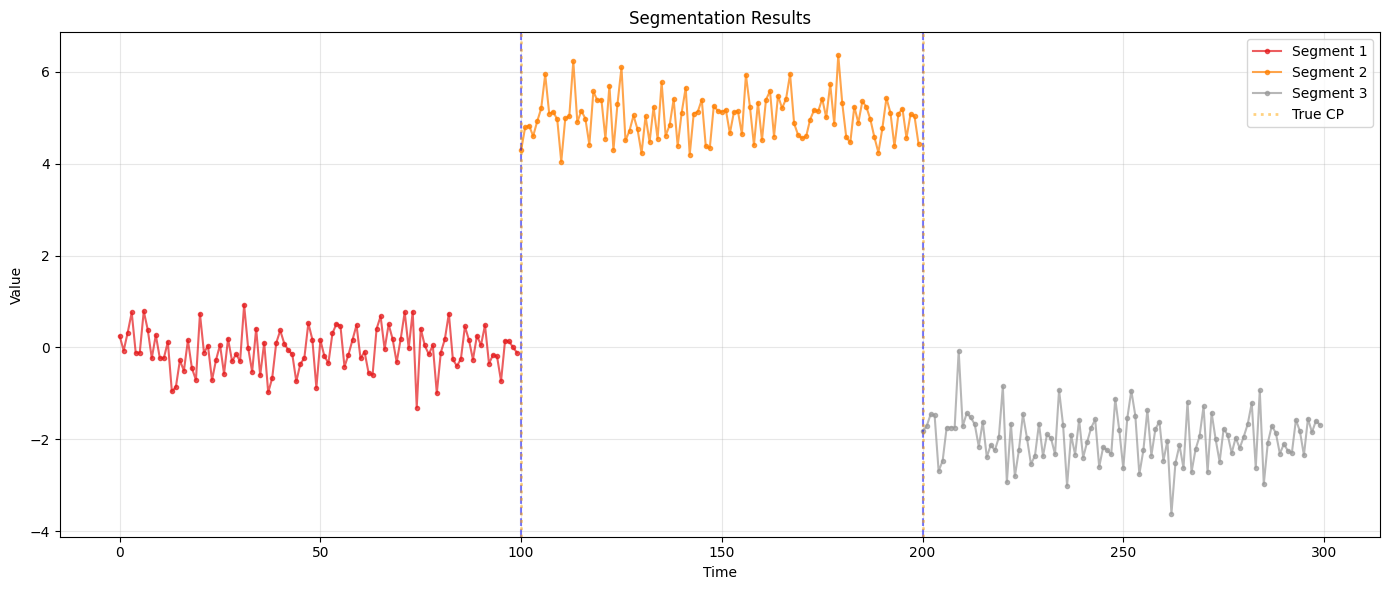

In [8]:
# Create visualization
fig, ax = plt.subplots(figsize=(14, 6))

# Plot each segment with different color
colors = plt.cm.Set1(np.linspace(0, 1, len(segments)))

for i, (start, end) in enumerate(segments):
    segment_data = data[start:end]
    segment_times = np.arange(start, end)
    ax.plot(segment_times, segment_data, 'o-', color=colors[i], 
            alpha=0.7, markersize=3, label=f'Segment {i+1}')

# Mark detected changepoints
for cp in changepoints:
    ax.axvline(cp.index, color='blue', linestyle='--', alpha=0.5, linewidth=1.5)

# Mark true changepoints
ax.axvline(100, color='orange', linestyle=':', alpha=0.5, linewidth=2, label='True CP')
ax.axvline(200, color='orange', linestyle=':', alpha=0.5, linewidth=2)

ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.set_title('Segmentation Results')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Run Length History

The **run length** $r_t$ is the time since the most recent changepoint. It is a latent variable in the BOCPD model.

### Statistical Interpretation

At each time $t$, we maintain a posterior distribution over run lengths:
$$P(r_t = r \mid x_{1:t}) \quad \text{for } r = 0, 1, \ldots, R_{max}$$

The **MAP (Maximum A Posteriori)** estimate is:
$$r_{MAP}(t) = \arg\max_r P(r_t = r \mid x_{1:t})$$

This represents the **most likely** run length given the data observed so far.

### Behavior Over Time

- **After a changepoint:** $r_{MAP} = 0$ (just started a new segment)
- **Stable period:** $r_{MAP}$ increases linearly (time since last changepoint)
- **At next changepoint:** $r_{MAP}$ drops back to 0

### Relation to Changepoint Detection

A changepoint at time $t$ means $r_t = 0$. Therefore:
- High $P(r_t = 0 \mid x_{1:t})$ indicates likely changepoint
- $r_{MAP} = 0$ means changepoint is the most probable explanation

Visualizing $r_{MAP}(t)$ over time shows the segmentation structure of the data.

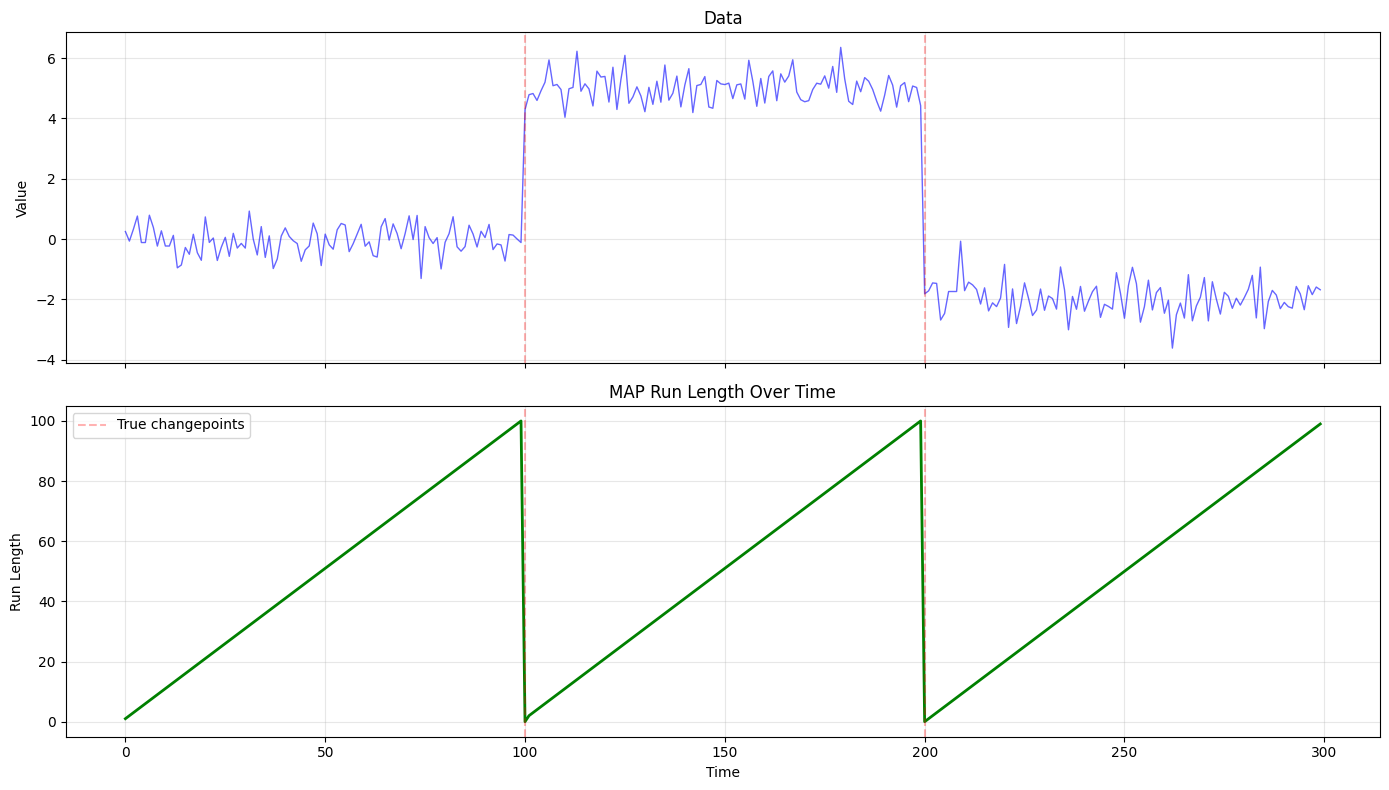

Run length resets to 0 at changepoints, then increases steadily


In [9]:
# Get MAP run length history
map_history = detector.get_map_history()

# Plot run length over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Data
ax1.plot(data, alpha=0.6, linewidth=1, color='blue')
ax1.axvline(100, color='red', linestyle='--', alpha=0.3)
ax1.axvline(200, color='red', linestyle='--', alpha=0.3)
ax1.set_ylabel('Value')
ax1.set_title('Data')
ax1.grid(True, alpha=0.3)

# Run length
ax2.plot(map_history, linewidth=2, color='green')
ax2.axvline(100, color='red', linestyle='--', alpha=0.3, label='True changepoints')
ax2.axvline(200, color='red', linestyle='--', alpha=0.3)
ax2.set_xlabel('Time')
ax2.set_ylabel('Run Length')
ax2.set_title('MAP Run Length Over Time')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Run length resets to 0 at changepoints, then increases steadily")

---
## Summary

### Key Takeaways

**Batch Mode:**
- Use for historical data analysis
- Faster due to reduced overhead
- Returns array of changepoint probabilities
- Method: `bocpd.batch_update(data)`

**Online Mode:**
- Use for streaming/real-time data
- Process one observation at a time
- Returns posterior distribution and CP probability
- Method: `bocpd.update(x)`

**OnlineChangeDetector:**
- Higher-level wrapper for online mode
- Automatic changepoint detection using MAP
- Built-in history tracking and segmentation
- Recommended for production systems

### Best Practices

1. **For Research/Analysis:** Use batch mode for speed
2. **For Production Systems:** Use OnlineChangeDetector
3. **For Custom Logic:** Use basic online mode with `bocpd.update()`
4. **Always:** Choose `lambda_` (hazard) based on expected segment length
---